In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame, read_excel
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import shap
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
import matplotlib.pyplot as plt

In [15]:
filename = "../DataBase/DataCollection.xlsx"
dataset: DataFrame = read_excel(filename, sheet_name="895 Records")
print(dataset.shape)

(895, 40)


`Variables Enconding`

In [ ]:
dissolve_encoding: dict[str, int] = {"NO": 0,"YES": 1}
sample_type_enconding: dict[str, int] = {"pellet": 0, "waste": 1, "fiber": 2, "film": 3, "powder": 4}

encoding: dict[str, dict[str, int]] = {
    "Dissolution": dissolve_encoding,
    "Sample type": sample_type_enconding
}
df: DataFrame = dataset.replace(encoding, inplace=False)

`Variables Normalization`

In [17]:
df = df.drop(columns=["Polymer_ID", "Solvent_ID", "Polymer", "Solvent"])

X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]


X_log = np.log1p(X)
min_max_scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
X_scaled = min_max_scaler.fit_transform(X_log)

df_log_minmax = DataFrame(X_scaled, columns = X.columns, index= X.index)
df_log_minmax["Dissolution"] = y

In [18]:
target = 'Dissolution'
X = df_log_minmax.drop(columns=target)
y = df_log_minmax[target]

`Cross-Validation` - Hyperparameter Search

In [19]:
# Hyperparameters to Evaluate
param_grid = {
    'hidden_layer_sizes': [(50,), (60,), (50,60)],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'learning_rate_init': [0.5, 0.05],
    'max_iter': [200, 500, 750]
}

In [20]:
acc_val_list = []
acc_train_list = []
acc_test_list = []
recall_test_list = []
best_params_list = []


for i in range(5):  
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=i, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=i, stratify=y_temp)

    print(f"\n{'='*30}\nStarting Iteration {i}\n{'='*30}")
 
    grid_search = GridSearchCV(MLPClassifier(random_state=i), param_grid, cv=5, scoring='accuracy', n_jobs =-1)
    grid_search.fit(X_val, y_val)
    best_params = grid_search.best_params_
    best_params_list.append(best_params)

    model = MLPClassifier(**best_params, random_state=i)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc_val = accuracy_score(y_val, y_val_pred)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    acc_val_list.append(acc_val)
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

    print(f"Best otimization:  {best_params}")
    print(f"Accuracy - Train:     {acc_train:.3f}")
    print(f"Accuracy - Validation:  {acc_val:.3f}")
    print(f"Accuracy - Test:      {acc_test:.3f}")


print("\n=== Final Results ===")
print(f"Accuracy - Train:     Mean = {np.mean(acc_train_list):.3f}, Standard Deviation = {np.std(acc_train_list):.3f}")
print(f"Accuracy - Validation: Mean = {np.mean(acc_val_list):.3f}, Standard Deviation = {np.std(acc_val_list):.3f}")
print(f"Accuracy - Test:      Mean = {np.mean(acc_test_list):.3f}, Standard Deviation = {np.std(acc_test_list):.3f}")


Starting Iteration 0
Best otimization:  {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 60), 'learning_rate': 'adaptive', 'learning_rate_init': 0.5, 'max_iter': 200, 'solver': 'sgd'}
Accuracy - Train:     0.973
Accuracy - Validation:  0.896
Accuracy - Test:      0.970

Starting Iteration 1
Best otimization:  {'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'learning_rate_init': 0.05, 'max_iter': 200, 'solver': 'sgd'}
Accuracy - Train:     0.848
Accuracy - Validation:  0.828
Accuracy - Test:      0.881

Starting Iteration 2
Best otimization:  {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'learning_rate_init': 0.5, 'max_iter': 200, 'solver': 'sgd'}
Accuracy - Train:     0.914
Accuracy - Validation:  0.896
Accuracy - Test:      0.837

Starting Iteration 3
Best otimization:  {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant'

`Cross-Validation` - Manual Fine-Tunning

In [21]:
#random_state = np.random.randint(0, 2**32)
#print(random_state)
random_state = 1826736192

In [22]:
# Hyperparameters to Evaluate across 5 different data splits
param_grid = {
    'hidden_layer_sizes': (50,),
    'activation': 'relu',
    'alpha': 0.001,               
    'learning_rate': 'constant',
    'learning_rate_init': 0.5,
    'solver': 'sgd',
    'max_iter': 200
}

In [23]:
acc_val_list = []
acc_train_list = []
acc_test_list = []
recall_test_list = []
best_params_list = []

for i in range(5): 
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=i, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=i, stratify=y_temp)

    print(f"\n{'='*30}\nStarting Iteration {i+1}\n{'='*30}")

    mlp_model = MLPClassifier(**param_grid, random_state = random_state)
    mlp_model.fit(X_train, y_train)

    y_val_pred = mlp_model.predict(X_val)
    y_train_pred = mlp_model.predict(X_train)
    y_test_pred = mlp_model.predict(X_test)

    acc_val = accuracy_score(y_val, y_val_pred)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    acc_val_list.append(acc_val)
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

    print(f"Running parameters:  {param_grid}")
    print(f"Accuracy - Train:     {acc_train:.4f}")
    print(f"Accuracy - Validation:  {acc_val:.4f}")
    print(f"Accuracy - Test:      {acc_test:.4f}")


print("\n=== Final Results ===")
print(f"Accuracy - Train:     Mean = {np.mean(acc_train_list):.4f}, Standard Deviation = {np.std(acc_train_list):.4f}")
print(f"Accuracy - Validation: Mean = {np.mean(acc_val_list):.4f}, Standard Deviation = {np.std(acc_val_list):.4f}")
print(f"Accuracy - Test:      Mean = {np.mean(acc_test_list):.4f}, Standard Deviation = {np.std(acc_test_list):.4f}")


Starting Iteration 1
Running parameters:  {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate': 'constant', 'learning_rate_init': 0.5, 'solver': 'sgd', 'max_iter': 200}
Accuracy - Train:     0.9585
Accuracy - Validation:  0.9104
Accuracy - Test:      0.9333

Starting Iteration 2
Running parameters:  {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate': 'constant', 'learning_rate_init': 0.5, 'solver': 'sgd', 'max_iter': 200}
Accuracy - Train:     0.9473
Accuracy - Validation:  0.8806
Accuracy - Test:      0.9037

Starting Iteration 3
Running parameters:  {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate': 'constant', 'learning_rate_init': 0.5, 'solver': 'sgd', 'max_iter': 200}
Accuracy - Train:     0.9665
Accuracy - Validation:  0.9403
Accuracy - Test:      0.9185

Starting Iteration 4
Running parameters:  {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate': 'c

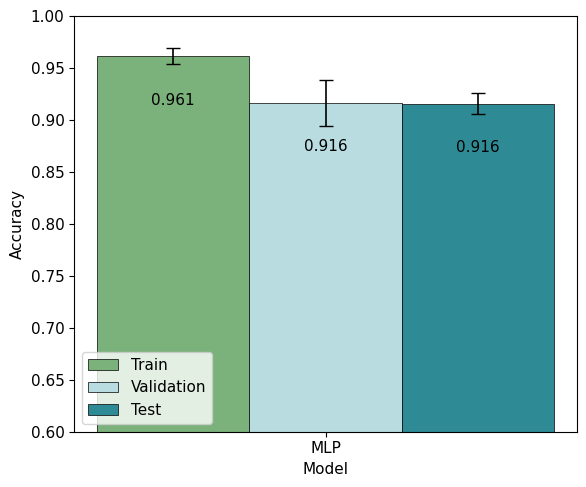

In [ ]:
means = [0.9613, 0.9164, 0.9156]
stds = [0.0078, 0.0223, 0.0100]
labels = ['Train', 'Validation', 'Test']
colors = ['#7BB17B', '#B8DCE0', '#2E8B96']

plt.rcParams.update({'font.size': 11})
x_center = 0
width = 0.25
positions = [x_center - width, x_center, x_center + width]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(positions, means, width, yerr=stds, color=colors,
              edgecolor='black', linewidth=0.5,
              capsize=5, error_kw={'elinewidth': 1.2, 'ecolor': 'black'})


for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean - 0.035,
            f'{mean:.3f}', ha='center', va='top', fontsize=11, color='black')

ax.set_ylim(0.60, 1.00)
ax.set_yticks(np.arange(0.60, 1.01, 0.05))
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_xticks([x_center])
ax.set_xticklabels(['MLP'], fontsize=11)
ax.tick_params(axis='both', labelsize=11)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec='black', lw=0.5) for c in colors]
ax.legend(legend_handles, labels, loc='lower left', frameon=True, fontsize=11)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

`XAI SHAP` - BeeSwarm Plot

In [24]:
mlp_model.fit(X, y)
background = shap.sample(X)
explainer = shap.KernelExplainer(mlp_model.predict_proba, background)
explanation = explainer(X)   
#shap_values_class0 = explanation[:, :, 0]
shap_values_class1 = explanation[:, :, 1]

100%|██████████| 895/895 [00:29<00:00, 30.22it/s]


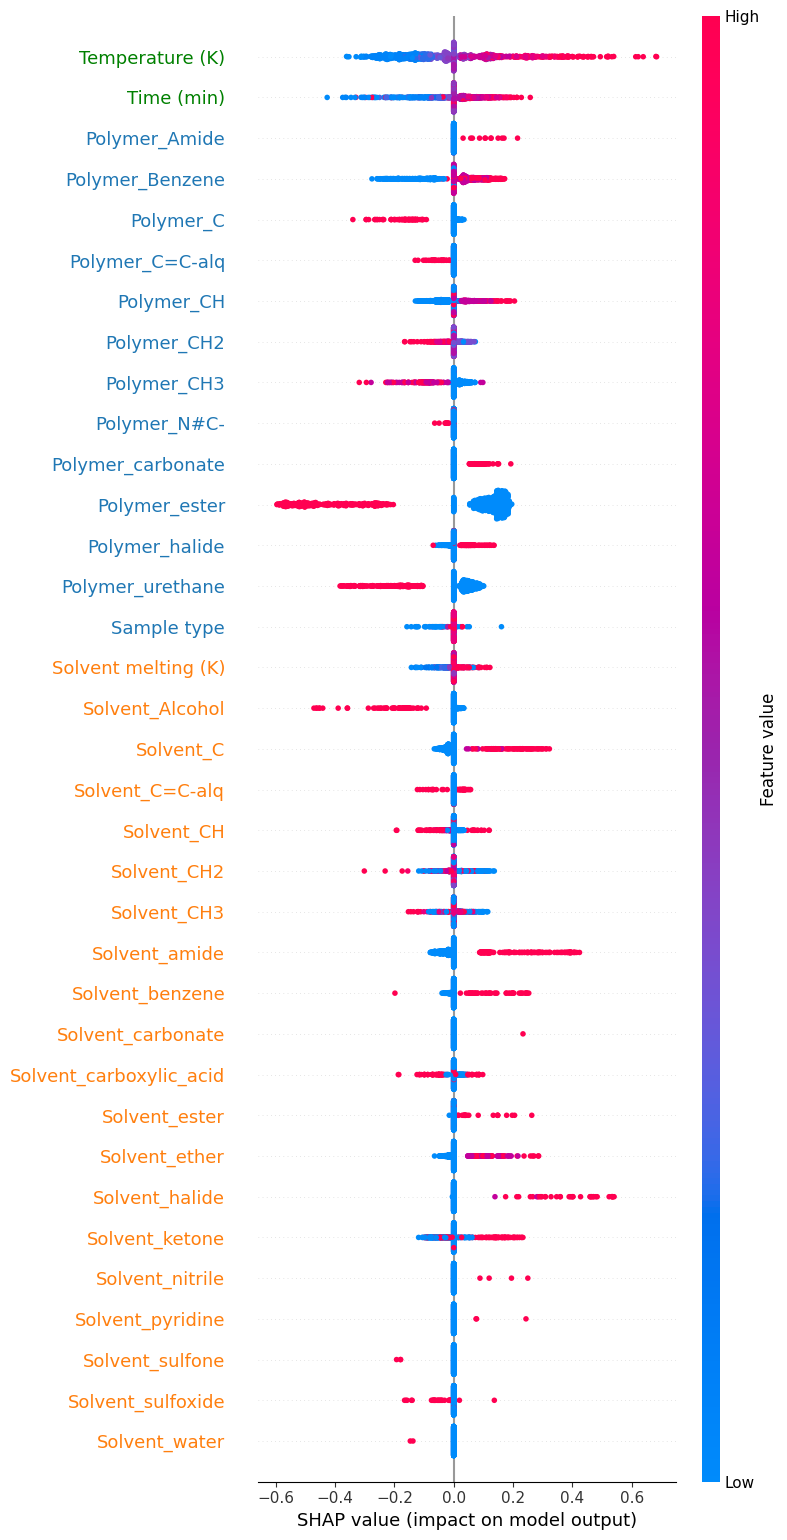

In [25]:
feature_order = [
    'Temperature (K)', 'Time (min)',
    'Polymer_Amide', 'Polymer_Benzene', 'Polymer_C', 'Polymer_C=C-alq',
    'Polymer_CH', 'Polymer_CH2', 'Polymer_CH3', 'Polymer_N#C-',
    'Polymer_carbonate', 'Polymer_ester', 'Polymer_halide', 'Polymer_urethane',
    'Sample type',
    'Solvent melting (K)',
    'Solvent_Alcohol', 'Solvent_C', 'Solvent_C=C-alq', 'Solvent_CH',
    'Solvent_CH2', 'Solvent_CH3', 'Solvent_amide', 'Solvent_benzene',
    'Solvent_carbonate', 'Solvent_carboxylic_acid', 'Solvent_ester',
    'Solvent_ether', 'Solvent_halide', 'Solvent_ketone', 'Solvent_nitrile',
    'Solvent_pyridine', 'Solvent_sulfone', 'Solvent_sulfoxide', 'Solvent_water',
]
sv = shap_values_class1[:, feature_order]

plt.figure(figsize=(10, 12))
shap.plots.beeswarm(
    sv,
    max_display=len(feature_order),
    order=np.arange(len(feature_order)),               
    show=False,
)

ax = plt.gca()              

def color_feature(name):
    if name in ('Temperature (K)', 'Time (min)'): return 'green'
    if name.startswith('Polymer') or name == 'Sample type': return 'tab:blue'
    if name.startswith('Solvent'): return 'tab:orange'

for label in ax.get_yticklabels():
    label.set_color(color_feature(label.get_text()))

plt.tight_layout()
plt.show()

`XAI SHAP` - Feature Relative Importance Plot

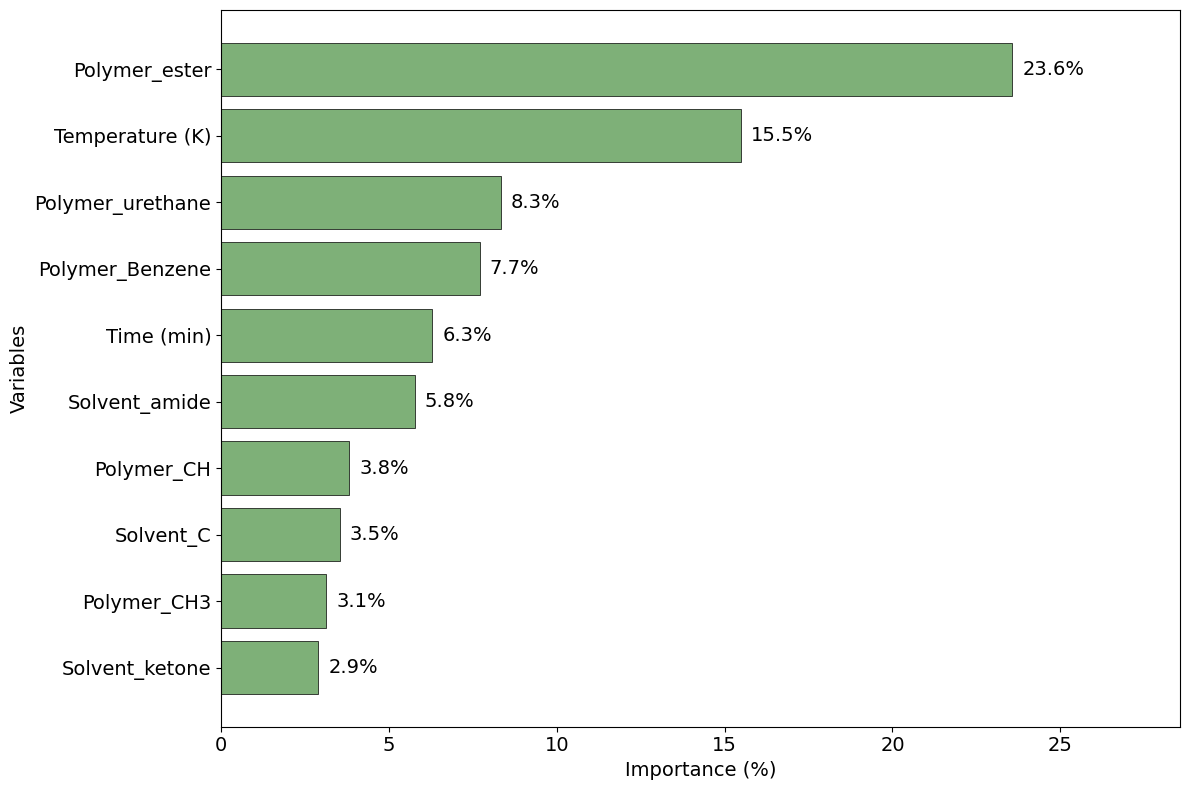

In [27]:
max_display = 10
mean_shap = np.mean(np.abs(shap_values_class1.values), axis=0)
importance_features_percentage = (mean_shap / np.sum(mean_shap)) * 100

feature_names = shap_values_class1.feature_names
data = sorted(zip(feature_names, importance_features_percentage), key=lambda x: x[1], reverse=False)
data = data[-max_display:]
sorted_names, sorted_values = zip(*data)

fig, ax = plt.subplots(figsize=(12, 8))

bar_color = '#7eb078' 
bars = ax.barh(sorted_names, sorted_values, color=bar_color, edgecolor='black', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', va='center', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("Importance (%)", fontsize=14)
ax.set_ylabel("Variables", fontsize=14)
ax.set_xlim(0, max(sorted_values) + 5)  

plt.tight_layout()
plt.show()